# Logistic Regression (Mathematical Intuition)

Logistic Regression is used for **binary classification problems**.

Instead of predicting continuous values like Linear Regression, it predicts probabilities.

Output range: **0 to 1**

## Linear Equation

We start with a linear equation:

z = w1x1 + w2x2 + ... + wn*xn + b

or in vector form:

z = w^T x + b

## Sigmoid Function

To convert z into probability, we apply the sigmoid function:

σ(z) = 1 / (1 + e^(-z))

Properties:
- Output between 0 and 1
- S-shaped curve

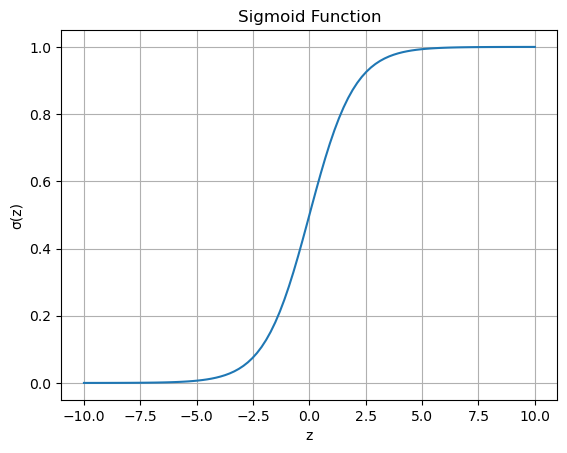

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
y = sigmoid(z)

plt.plot(z, y)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.grid()
plt.show()

## Prediction

We convert probability into class:

if σ(z) >= 0.5 → class 1  
else → class 0

## Cost Function

Linear regression uses MSE, but here we use **Log Loss (Cross Entropy)**:

J(w) = - (1/m) Σ [ y log(h(x)) + (1 - y) log(1 - h(x)) ]

Where:
- h(x) = sigmoid(z)
- m = number of samples

In [2]:
def log_loss(y_true, y_pred):
    m = len(y_true)
    return -(1/m) * np.sum(
        y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)
    )

## Gradient Descent

We minimize cost using gradient descent:

w = w - α * ∂J/∂w  
b = b - α * ∂J/∂b

In [3]:
def gradient_descent(X, y, lr=0.01, epochs=1000):
    m, n = X.shape
    w = np.zeros(n)
    b = 0

    for _ in range(epochs):
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)

        dw = (1/m) * np.dot(X.T, (y_pred - y))
        db = (1/m) * np.sum(y_pred - y)

        w -= lr * dw
        b -= lr * db

    return w, b

In [4]:
# Sample dataset
X = np.array([[1,2], [2,3], [3,4], [4,5]])
y = np.array([0, 0, 1, 1])

# Train
w, b = gradient_descent(X, y)

# Predict
z = np.dot(X, w) + b
preds = sigmoid(z)

print("Predictions:", preds)
print("Classes:", (preds >= 0.5).astype(int))

Predictions: [0.34961942 0.52123365 0.68797817 0.81703428]
Classes: [0 1 1 1]


## Summary

- Logistic Regression uses **sigmoid function**
- Outputs **probabilities**
- Uses **log loss (cross entropy)**
- Optimized using **gradient descent**
- Works best for **binary classification**